<a href="https://colab.research.google.com/github/Krishna-matic/python_practice/blob/main/Assignment_Lasso_RIdge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DataSetForpython/student_habits_performance.csv')
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [ ]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [ ]:
df.columns

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'part_time_job', 'attendance_percentage',
       'sleep_hours', 'diet_quality', 'exercise_frequency',
       'parental_education_level', 'internet_quality', 'mental_health_rating',
       'extracurricular_participation', 'exam_score'],
      dtype='object')

In [ ]:
df = df.drop(columns=["student_id"])

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


In [ ]:
df.shape

(1000, 15)

In [ ]:
df["parental_education_level"].fillna(# Handling null values
    df["parental_education_level"].mode()[0],
    inplace=True
)

/tmp/ipykernel_1099/1617204667.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["parental_education_level"].fillna(


In [ ]:
df.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,481
Male,477
Other,42


In [ ]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [ ]:
df['part_time_job'].value_counts()

,count
part_time_job,
No,785
Yes,215


In [ ]:
df['part_time_job'] = df['part_time_job'].map({'Yes':1,'No':0})

In [ ]:
df['diet_quality'].value_counts()

,count
diet_quality,
Fair,437
Good,378
Poor,185


In [ ]:
df['diet_quality'] = df['diet_quality'].map({'Poor':0,'Fair':1,'Good':2})

In [ ]:
df['parental_education_level'].value_counts()

,count
parental_education_level,
High School,483
Bachelor,350
Master,167


In [ ]:
df['parental_education_level'] = df['parental_education_level'].map({'High School':0,'Bachelor':1,'Master':2})

In [ ]:
df['internet_quality'].value_counts()

,count
internet_quality,
Good,447
Average,391
Poor,162


In [ ]:
df['internet_quality'] = df['internet_quality'].map({'Poor':0,'Average':1,'Good':2})

In [ ]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,gender_Male,gender_Other
0,23,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,Yes,56.2,False,False
1,20,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,No,100.0,False,False
2,21,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,No,34.3,True,False
3,23,1.0,3.9,1.0,0,71.0,9.2,0,4,2,2,1,Yes,26.8,False,False
4,19,5.0,4.4,0.5,0,90.9,4.9,1,3,2,2,1,No,66.4,False,False


In [ ]:
df['extracurricular_participation'].value_counts()

,count
extracurricular_participation,
No,682
Yes,318


In [ ]:
df['extracurricular_participation'] = df['extracurricular_participation'].map({'Yes':1,'No':0})

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   study_hours_per_day            1000 non-null   float64
 2   social_media_hours             1000 non-null   float64
 3   netflix_hours                  1000 non-null   float64
 4   part_time_job                  1000 non-null   int64  
 5   attendance_percentage          1000 non-null   float64
 6   sleep_hours                    1000 non-null   float64
 7   diet_quality                   1000 non-null   int64  
 8   exercise_frequency             1000 non-null   int64  
 9   parental_education_level       1000 non-null   int64  
 10  internet_quality               1000 non-null   int64  
 11  mental_health_rating           1000 non-null   int64  
 12  extracurricular_participation  1000 non-null   in

In [ ]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,0.215000,84.131700,6.470100,1.19300,3.042000,0.684000,1.285000,5.438000,0.318000,69.601500
std,2.3081,1.46889,1.172422,1.075118,0.411028,9.399246,1.226377,0.72545,2.025423,0.742088,0.726845,2.847501,0.465932,16.888564
min,17.0000,0.00000,0.000000,0.000000,0.000000,56.000000,3.200000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,0.000000,78.000000,5.600000,1.00000,1.000000,0.000000,1.000000,3.000000,0.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,0.000000,84.400000,6.500000,1.00000,3.000000,1.000000,1.000000,5.000000,0.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,0.000000,91.025000,7.300000,2.00000,5.000000,1.000000,2.000000,8.000000,1.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,1.000000,100.000000,10.000000,2.00000,6.000000,2.000000,2.000000,10.000000,1.000000,100.000000


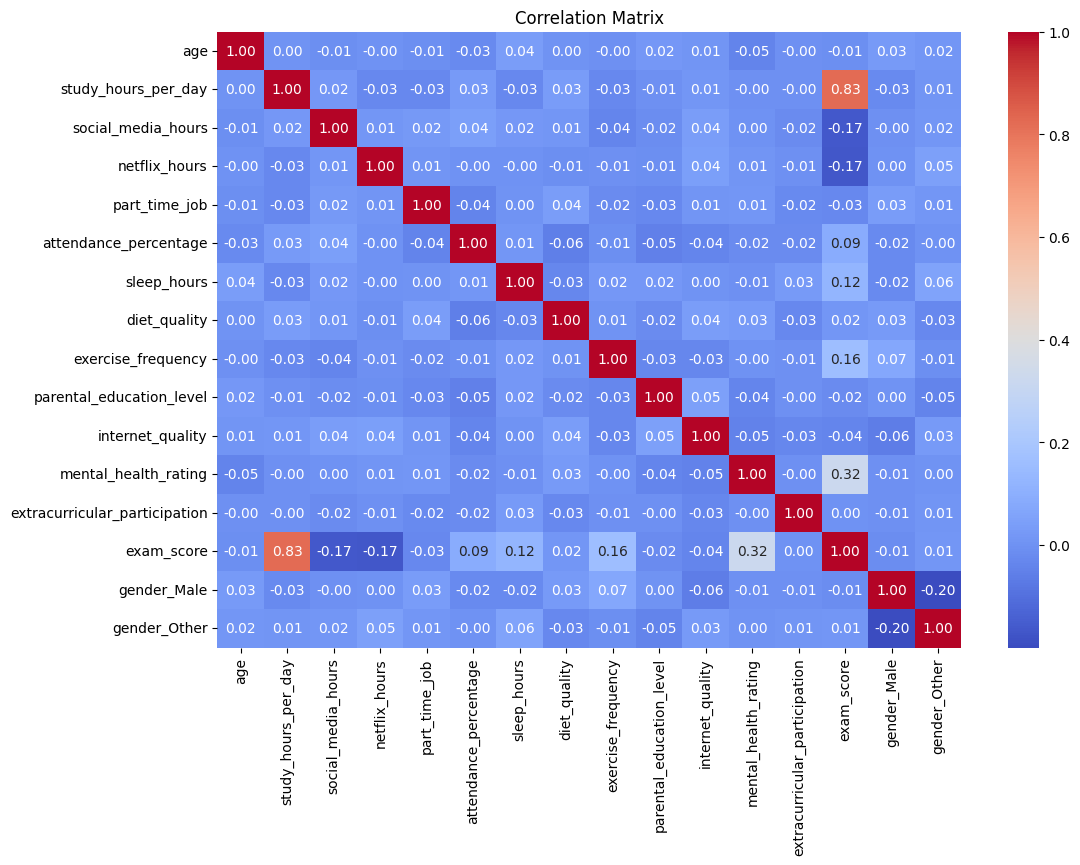

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

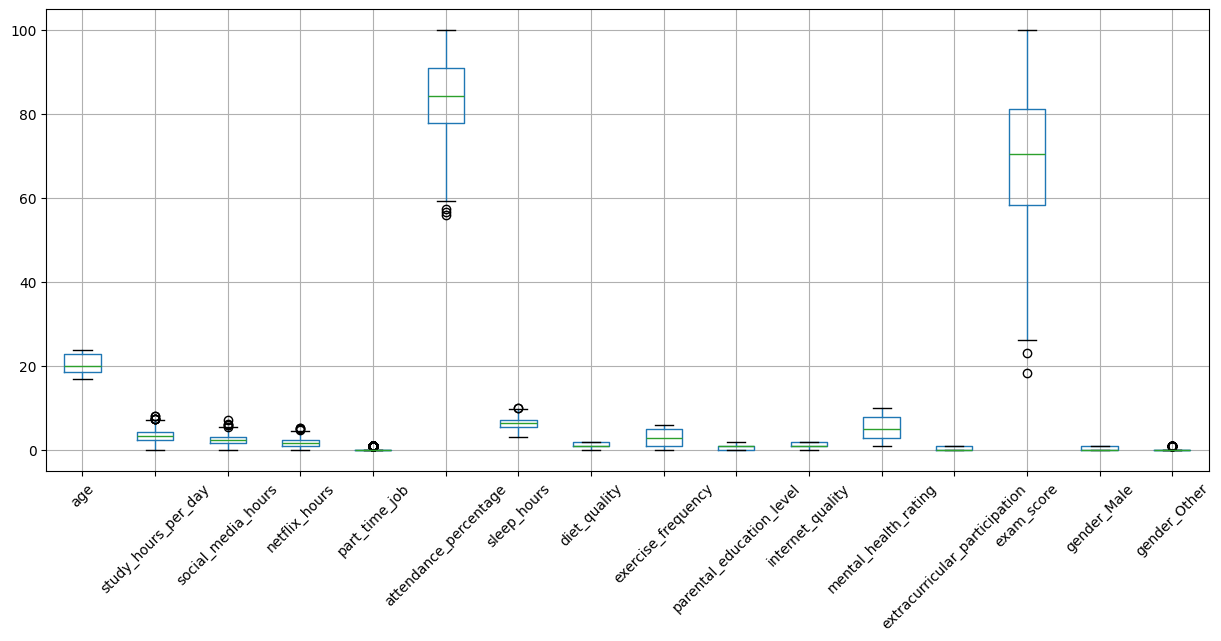

In [ ]:
df.boxplot(figsize=(15,6))#Checking for ouliers
plt.xticks(rotation=45)
plt.show()

**EDA Completed**

In [ ]:
x = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [ ]:
x.shape

(1000, 15)

In [ ]:
y.shape

(1000,)

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
x_train.shape

(800, 15)

In [ ]:
x_test.shape

(200, 15)

In [ ]:
y_train.shape

(800,)

In [ ]:
y_test.shape

(200,)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(x_test_scaled)

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})
comparison.head(10)

,Actual,Predicted
521,64.2,65.973887
737,72.7,74.751775
740,79.0,78.600092
660,79.5,73.741433
411,58.2,61.419620
678,53.4,54.625185
626,70.8,75.442606
513,62.5,55.422291
859,36.8,41.059099
136,67.6,72.365949


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 4.144451134425766
MSE : 25.94184786470818
RMSE: 5.093314035547796
R² Score: 0.8988342264221523


**Lasso**

In [ ]:
lasso = Lasso(alpha=1.0)
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_test_scaled)

In [ ]:
comparison_Lasso = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lasso
})
comparison_Lasso.head(10)

,Actual,Predicted
521,64.2,66.401781
737,72.7,76.605383
740,79.0,76.976247
660,79.5,72.983706
411,58.2,61.848608
678,53.4,58.733450
626,70.8,73.810444
513,62.5,57.517718
859,36.8,44.555762
136,67.6,74.681595


In [ ]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R² Score:", r2_lasso)

MAE : 4.632550072116559
MSE : 33.27373906310874
RMSE: 5.768339367886458
R² Score: 0.870241951548631


**Ridge**

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_test_scaled)

In [ ]:
comparison_ridge = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_ridge
})
comparison_ridge.head(10)

,Actual,Predicted
521,64.2,65.978555
737,72.7,74.743486
740,79.0,78.587820
660,79.5,73.739154
411,58.2,61.427503
678,53.4,54.642045
626,70.8,75.434869
513,62.5,55.438122
859,36.8,41.097069
136,67.6,72.363432


In [ ]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge= r2_score(y_test, y_pred_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R² Score:", r2_ridge)

MAE : 4.14613951187081
MSE : 25.954885768763802
RMSE: 5.094593778581743
R² Score: 0.8987833823320743


**Hyper Tuning for Lasso**

In [ ]:
from sklearn.model_selection import GridSearchCV
para = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
lasso = Lasso()
grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=para,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_lasso.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=Lasso(), n_jobs=-1,
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [ ]:
print("Best Alpha:", grid_lasso.best_params_)
print("Best CV Score:", grid_lasso.best_score_)

Best Alpha: {'alpha': 0.1}
Best CV Score: 0.8957664052893127


In [ ]:
best_lasso = grid_lasso.best_estimator_

y_pred_best_lasso = best_lasso.predict(x_test_scaled)

In [ ]:
mae_best = mean_absolute_error(y_test, y_pred_best_lasso)
mse_best = mean_squared_error(y_test, y_pred_best_lasso)
rmse_best = np.sqrt(mse)
r2_best = r2_score(y_test, y_pred_best_lasso)
print("MAE :", mae_best)
print("MSE :", mse_best)
print("RMSE:", rmse_best)
print("R² :", r2_best)

MAE : 4.1476788645173714
MSE : 26.034477563361133
RMSE: 5.093314035547796
R² : 0.8984729971385106
